# Barycenter Computation with the Back-and-Forth Method

The dual barycenter problem
$$
\min_{\nu} \sum_{j=1}^{n} \lambda_j W_2^2 (\mu_j, \nu)
$$
by considering the dual problem can be rewritten into
$$
...
$$

The inner $\min$ can be evaluated to give us the following optimality condition
$$
    \sum_{j=1}^{n} \lambda_j \psi_j (y) = 0
$$

Under the Monge problem and the quadratic cost the transport map $T_j$ of transport $\nu \to \mu_j$ is expressed via the potential $\psi_j$
$$
    T_j (y) = y - \nabla \psi_j (y)
$$
the optimality condition derivative
$$
    \sum_{j=1}^{n} \lambda_j \nabla \psi_j (y) = 0
$$
becomes
$$
    \sum_{j=1}^{n} \lambda_j (y - T_j (y)) = 0
    \implies y = \sum_{j=1}^{n} \lambda_j T_j (y)
$$

That mean that at the optimal $\nu^*$ the weighted sum of the monge maps $T_j$ results in the identity map $\operatorname{Id}$.

## Ring-Diamond-Square Example

We now build three simple 2D probability densities on the same grid and use the back-and-forth barycenter iteration to recover their Wasserstein barycenter.

In [ ]:
import sys, os
from jax import config

os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
os.environ['XLA_PYTHON_CLIENT_ALLOCATOR'] = 'platform'
config.update("jax_enable_x64", True)
sys.path.insert(0, os.path.abspath(os.path.join("..")))

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from uot.data.measure import GridMeasure

jax.config.update("jax_enable_x64", True)

from uot.utils.generator_helpers.get_axes import get_axes

In [2]:
from __future__ import annotations

from collections.abc import Sequence
from typing import Optional
from functools import reduce

import numpy as np
import jax.numpy as jnp

from uot.data.measure import GridMeasure
from uot.utils.central_gradient_nd import _central_gradient_nd

from uot.solvers.back_and_forth.method import backnforth_sqeuclidean_nd
from uot.solvers.back_and_forth.pushforward import adaptive_pushforward_nd
from uot.solvers.back_and_forth.forward_pushforward import cic_pushforward_nd

In [ ]:
def backnforth_barycenter_sqeuclidean_nd(
    weights: Sequence[float],
    measures_weights: Sequence[jnp.ndarray],
    coordinates: Sequence[jnp.ndarray],
    barycenter_init: jnp.ndarray | None = None,
    outer_maxiter: int = 15,
    stopping_tol: float = 5e-4,
    relaxation: float = 1.0,
    transport_stepsize: float = 1.0,
    transport_maxiter: int = 500,
    transport_tol: float = 1e-3,
    transport_error_metric: str = 'h1_psi_relative',
    pushforward_fn=adaptive_pushforward_nd,
):
    if barycenter_init is None:
        barycenter_init = reduce(lambda a, b: a + b, measures_weights)  # arithmetic mean
    barycenter_density = jnp.clip(barycenter_init, 0.0)
    barycenter_density = barycenter_density / jnp.maximum(
        barycenter_density.sum(), jnp.finfo(barycenter_density.dtype).eps
    )

    history = []
    pushforward_path = []
    debug_snapshots = []
    pair_debug_info = []
    relaxation = float(relaxation)
    if not (0.0 < relaxation <= 1.0):
        raise ValueError("relaxation must lie in (0, 1].")

    for outer_iter in range(outer_maxiter):
        iteration_snapshot = {"mu": np.asarray(barycenter_density), "nus": [np.asarray(w) for w in measures_weights]}
        iteration_pairs = []
        psi_accum = jnp.zeros_like(barycenter_density)
        max_transport_error = 0.0

        for lambd, weights in zip(weights, measures_weights):
            call_debug = {"mu": np.asarray(barycenter_density), "nu": np.asarray(weights)}
            (
                iterations,
                _,
                psi,
                _,
                rho_mu,
                _,
                _,
                _,
            ) = backnforth_sqeuclidean_nd(
                mu=barycenter_density,
                nu=weights,
                coordinates=coordinates,
                stepsize=transport_stepsize,
                maxiterations=transport_maxiter,
                tolerance=transport_tol,
                progressbar=False,
                pushforward_fn=pushforward_fn,
                error_metric=transport_error_metric,
            )
            print(f"Internal: bfm converged after {iterations} iterations")
            psi_accum = psi_accum + lambd * psi
            call_debug["pushforward"] = np.asarray(rho_mu)
            iteration_pairs.append(call_debug)
            pair_error = jnp.sum(jnp.abs(rho_mu - weights))
            max_transport_error = max(float(pair_error), max_transport_error)

        grad_residual = _central_gradient_nd(psi_accum)
        residual = float(jnp.max(jnp.abs(grad_residual)))

        pushed_density, _ = pushforward_fn(barycenter_density, -psi_accum)
        pushforward_path.append(np.asarray(pushed_density))
        barycenter_density = (
            (1.0 - relaxation) * barycenter_density + relaxation * pushed_density
        )
        barycenter_density = jnp.clip(barycenter_density, 0.0)
        barycenter_density = barycenter_density / jnp.maximum(
            barycenter_density.sum(), jnp.finfo(barycenter_density.dtype).eps
        )

        iteration_snapshot["output"] = np.asarray(barycenter_density)
        debug_snapshots.append(iteration_snapshot)

        pair_debug_info.append(iteration_pairs)

        history.append(
            {
                "outer_iter": outer_iter,
                "residual": residual,
                "max_transport_error": max_transport_error,
            }
        )
        # if residual < stopping_tol:
        #     break
    diagnostics = {
        "history": history,
        "iterations": len(history),
        "final_residual": history[-1]["residual"] if history else 0.0,
        "max_transport_error": history[-1]["max_transport_error"] if history else 0.0,
        "pushforward_path": pushforward_path,
        "debug_snapshots": debug_snapshots,
        "pair_debug_info": pair_debug_info,
    }
    return barycenter_density, diagnostics


In [4]:
grid_size = 128
axes = get_axes(dim=2, borders=(0.0, 1.0), n_points=grid_size, cell_discretization='cell-centered')
# axes = [np.linspace(0.0, 1.0, grid_size), np.linspace(0.0, 1.0, grid_size)]
X, Y = np.meshgrid(axes[0], axes[1], indexing="ij")

def normalize_field(field, eps=1e-9):
    field = np.clip(field.astype(np.float64), 0.0, None)
    total = field.sum()
    return field / total if total > eps else field

def diamond_mask(center_x, center_y, radius):
    return (np.abs(X - center_x) + np.abs(Y - center_y)) <= radius


In [5]:
ring_outer = 0.28
ring_inner = 0.16
ring_density = normalize_field(
    (((X - 0.5) ** 2 + (Y - 0.5) ** 2) <= ring_outer ** 2)
    & (((X - 0.5) ** 2 + (Y - 0.5) ** 2) >= ring_inner ** 2)
)
diamond_density = normalize_field(diamond_mask(0.5, 0.5, 0.28))
square_density = normalize_field((np.abs(X - 0.5) <= 0.2) & (np.abs(Y - 0.5) <= 0.2))

# measures_weights = [ring_density, diamond_density, square_density]

# ring_measure = GridMeasure(axes, ring_density, name="ring")
# diamond_measure = GridMeasure(axes, diamond_density, name="diamond")
# square_measure = GridMeasure(axes, square_density, name="square")
# measures = [ring_measure, diamond_measure, square_measure]
shape_fields = {
    "Ring": ring_density,
    "Diamond": diamond_density,
    "Square": square_density,
}


In [6]:
measures_weights = [ring_density, diamond_density, square_density]
barycenter_density, diagnostics = backnforth_barycenter_sqeuclidean_nd(
    weights=[1/4, 1/2, 1/4],
    measures_weights=measures_weights,
    coordinates=axes,
    outer_maxiter=3,
    stopping_tol=2e-4,
    relaxation=1.0,
    transport_stepsize=1.0,
    transport_maxiter=1_000,
    transport_tol=1e-8,
    pushforward_fn=cic_pushforward_nd,
)
# barycenter_density = np.asarray(barycenter_measure.weights_nd)
print(f"completed {diagnostics['iterations']} outer iters")
print(f"final residual: {diagnostics['final_residual']:.2e}")
print(f"max pushforward error: {diagnostics['max_transport_error']:.2e}")


Internal: bfm converged after 133 iterations
Internal: bfm converged after 217 iterations
Internal: bfm converged after 214 iterations
Internal: bfm converged after 158 iterations
Internal: bfm converged after 130 iterations
Internal: bfm converged after 218 iterations
Internal: bfm converged after 159 iterations
Internal: bfm converged after 131 iterations
Internal: bfm converged after 147 iterations
completed 3 outer iters
final residual: 0.00e+00
max pushforward error: 2.20e-01


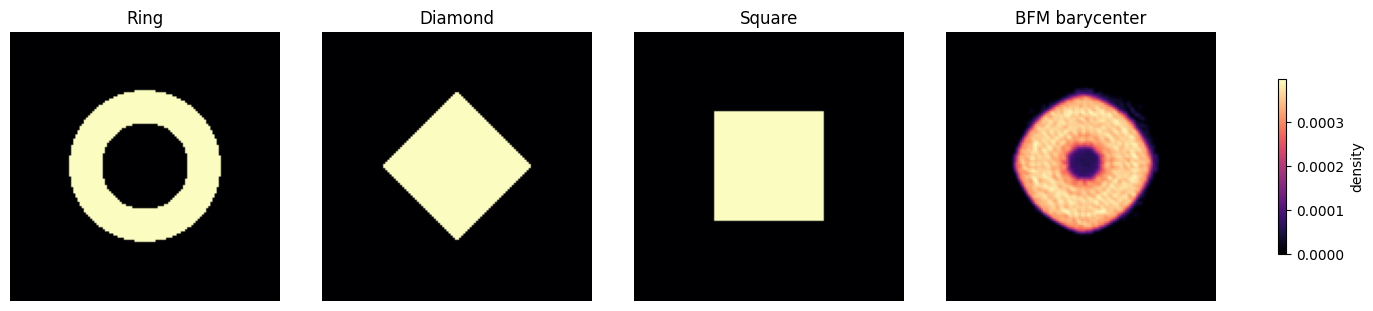

In [7]:
fig, axarr = plt.subplots(1, 4, figsize=(14, 3), constrained_layout=True)
titles = list(shape_fields.keys()) + ['BFM barycenter']
fields = list(shape_fields.values()) + [barycenter_density]
for ax, title, field in zip(axarr, titles, fields):
    im = ax.imshow(field, origin='lower', cmap='magma')
    ax.set_title(title)
    ax.axis('off')
fig.colorbar(im, ax=axarr.tolist(), shrink=0.65, label='density')


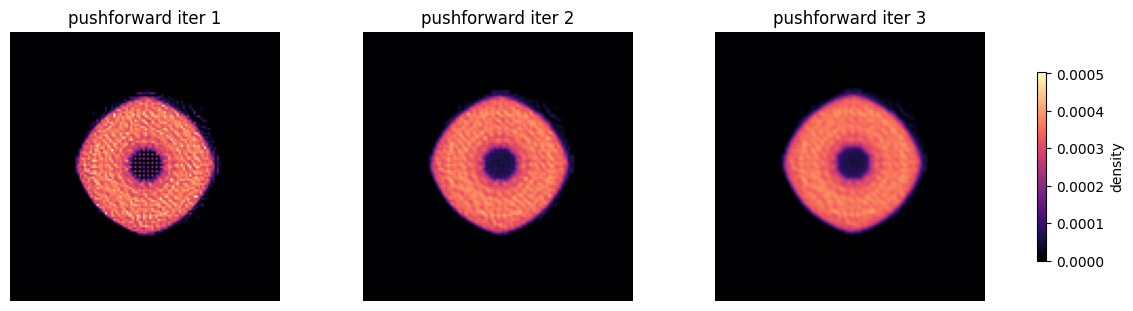

In [8]:
pushforward_evolution = diagnostics.get('pushforward_path', [])
if pushforward_evolution:
    cols = min(len(pushforward_evolution), 5)
    rows = int(np.ceil(len(pushforward_evolution) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3 * rows), constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()
    vmin = min(density.min() for density in pushforward_evolution)
    vmax = max(density.max() for density in pushforward_evolution)
    for idx, (ax, density) in enumerate(zip(axes, pushforward_evolution)):
        im = ax.imshow(density, origin='lower', cmap='magma', vmin=vmin, vmax=vmax)
        ax.set_title(f'pushforward iter {idx + 1}')
        ax.axis('off')
    for ax in axes[len(pushforward_evolution):]:
        ax.axis('off')
    fig.colorbar(im, ax=list(axes), shrink=0.7, label='density')
else:
    print('No pushforward evolution recorded.')


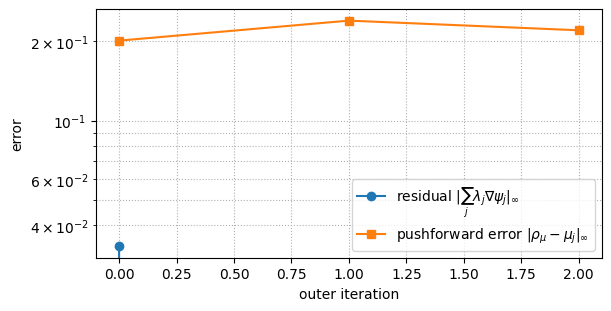

In [9]:
history = diagnostics['history']
iters = [step['outer_iter'] for step in history]
residuals = [step['residual'] for step in history]
push_errors = [step['max_transport_error'] for step in history]
fig, ax = plt.subplots(1, 1, figsize=(6, 3), constrained_layout=True)
ax.plot(iters, residuals, marker='o', label='residual $|\\sum_j \\lambda_j \\nabla \\psi_j |_\\infty$')
ax.plot(iters, push_errors, marker='s', label='pushforward error $|\\rho_{\\mu}-\\mu_j|_\\infty$')
ax.set_yscale('log')
ax.set_xlabel('outer iteration')
ax.set_ylabel('error')
ax.legend()
ax.grid(True, which='both', ls=':')


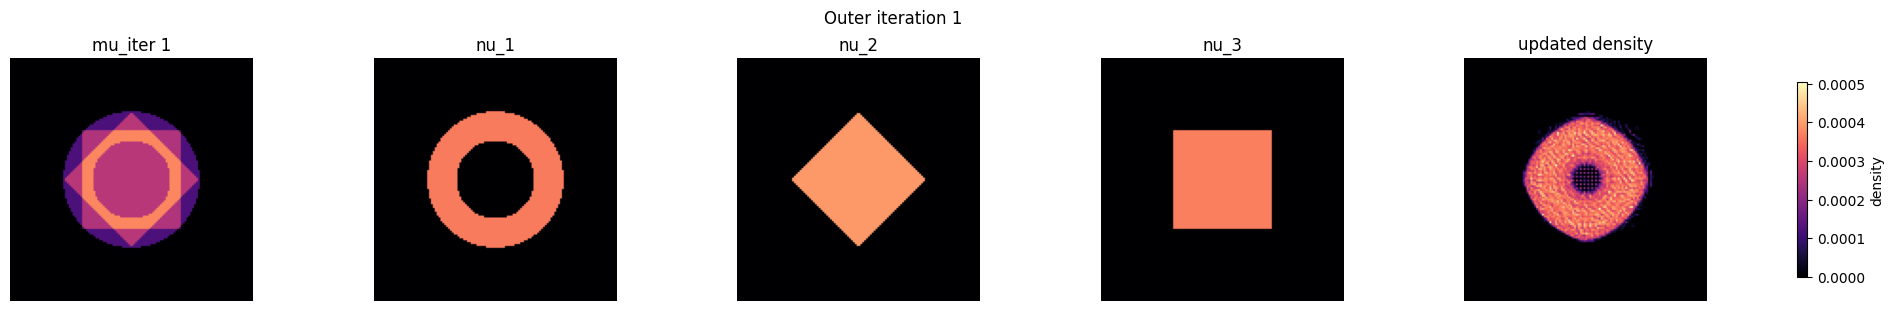

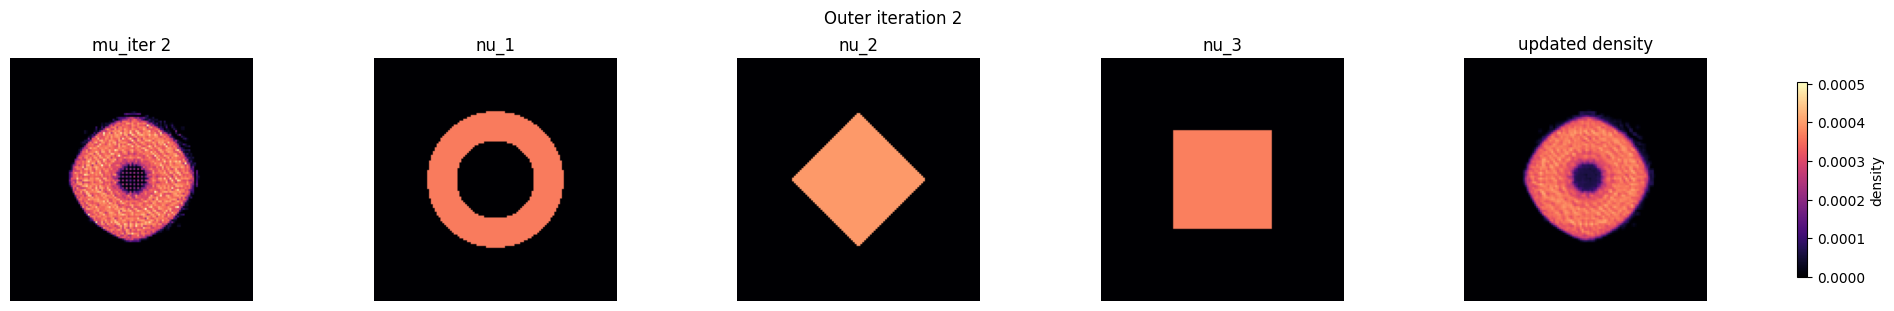

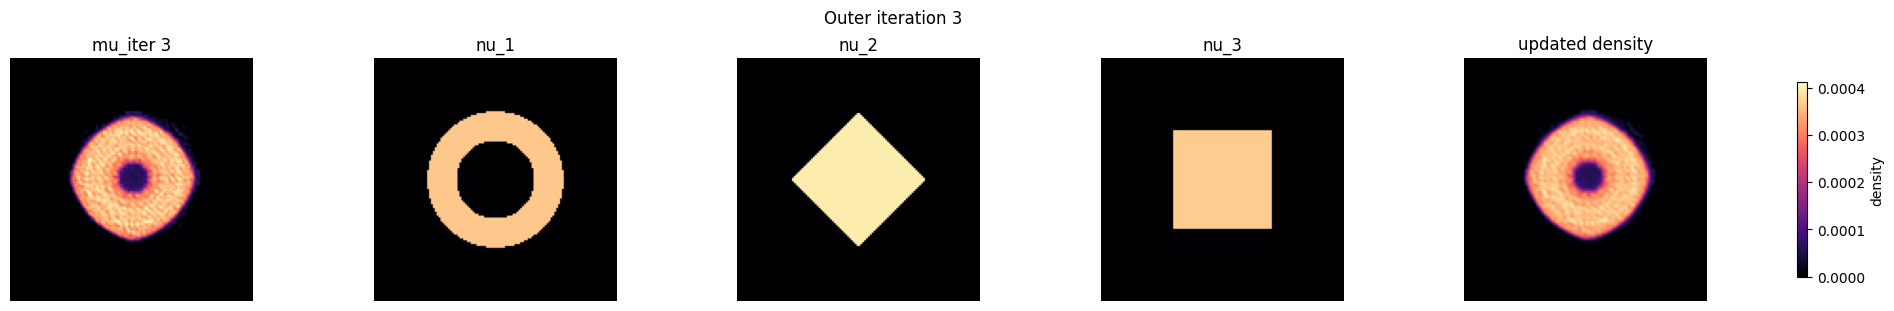

In [10]:
debug_snapshots = diagnostics.get('debug_snapshots', [])
if not debug_snapshots:
    print('No debug snapshots recorded.')
else:
    for iter_idx, snapshot in enumerate(debug_snapshots, start=1):
        fields = [snapshot['mu']] + snapshot['nus'] + [snapshot['output']]
        titles = [f'mu_iter {iter_idx}'] + [f'nu_{j+1}' for j in range(len(snapshot['nus']))] + ['updated density']
        vmin = min(float(np.min(f)) for f in fields)
        vmax = max(float(np.max(f)) for f in fields)
        fig, axes = plt.subplots(1, len(fields), figsize=(4 * len(fields), 3), constrained_layout=True)
        if len(fields) == 1:
            axes = [axes]
        for ax, field, title in zip(axes, fields, titles):
            im = ax.imshow(field, origin='lower', cmap='magma', vmin=vmin, vmax=vmax)
            ax.set_title(title)
            ax.axis('off')
        fig.suptitle(f'Outer iteration {iter_idx}')
        fig.colorbar(im, ax=axes, shrink=0.8, label='density')


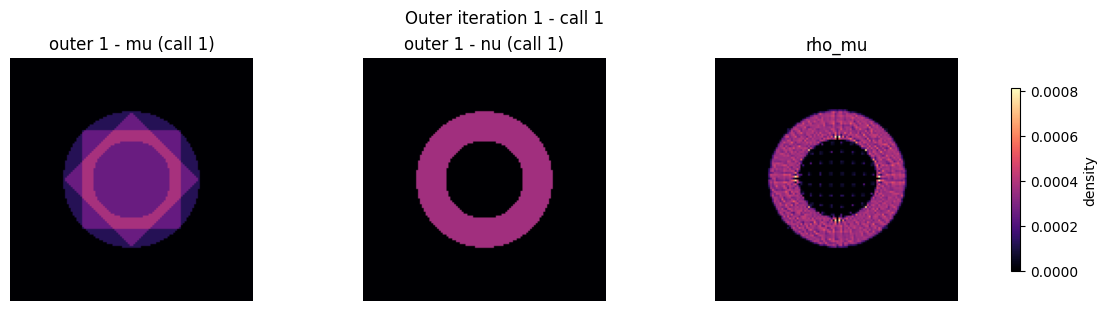

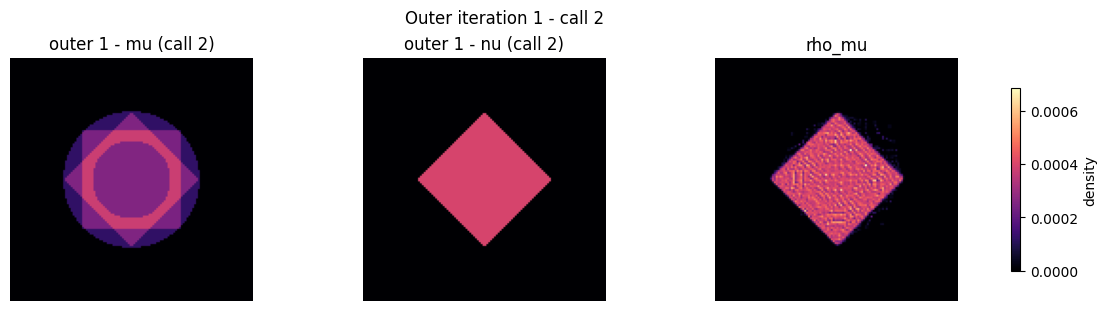

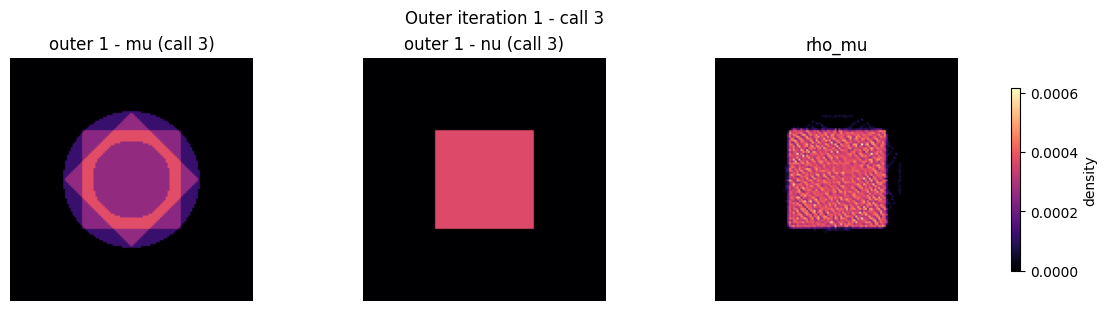

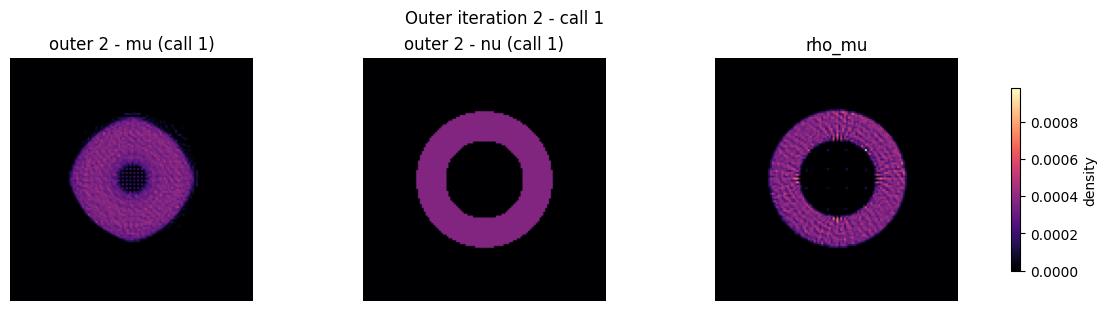

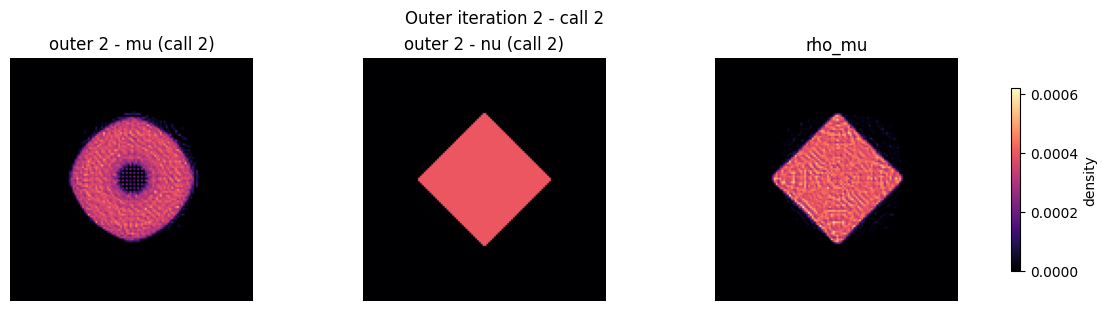

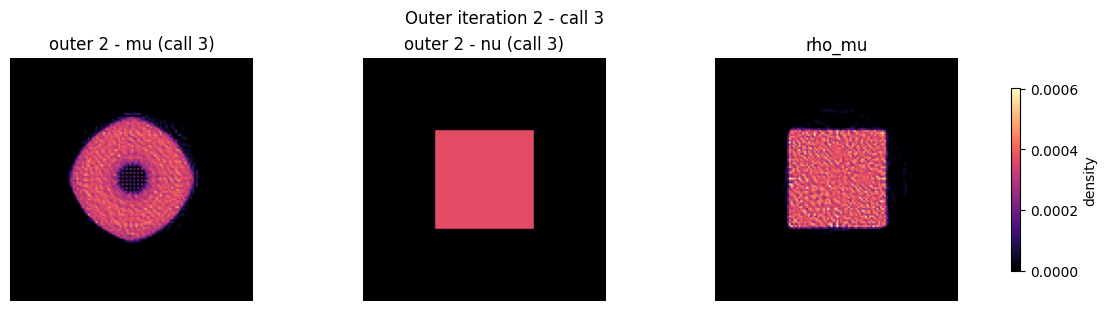

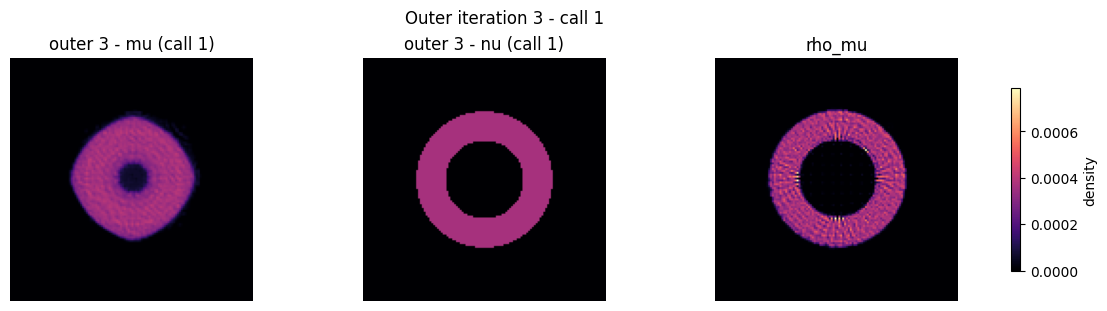

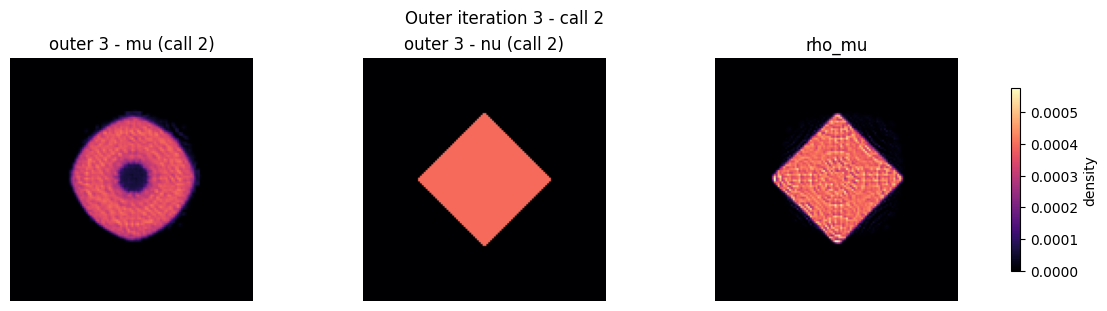

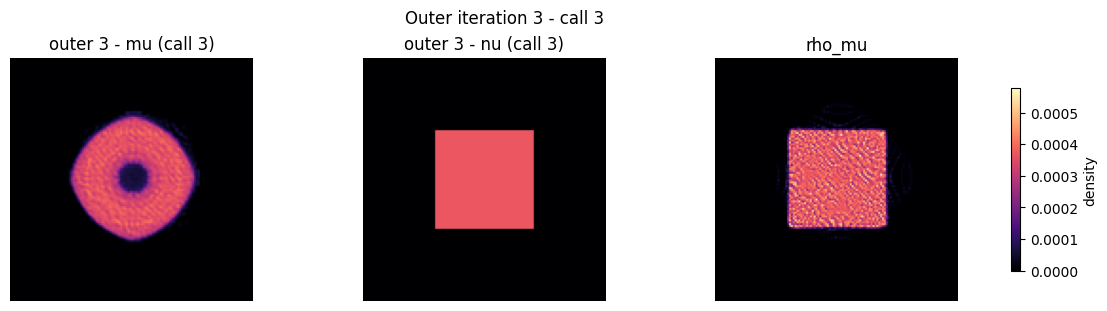

In [11]:
pair_debug = diagnostics.get('pair_debug_info', [])
if not pair_debug:
    print('No pairwise debug info recorded.')
else:
    for outer_idx, pair_list in enumerate(pair_debug, start=1):
        for pair_idx, pair in enumerate(pair_list, start=1):
            fields = [pair['mu'], pair['nu'], pair['pushforward']]
            titles = [f'outer {outer_idx} - mu (call {pair_idx})', f'outer {outer_idx} - nu (call {pair_idx})', 'rho_mu']
            vmin = min(float(np.min(f)) for f in fields)
            vmax = max(float(np.max(f)) for f in fields)
            fig, axes = plt.subplots(1, len(fields), figsize=(4 * len(fields), 3), constrained_layout=True)
            for ax, field, title in zip(axes, fields, titles):
                im = ax.imshow(field, origin='lower', cmap='magma', vmin=vmin, vmax=vmax)
                ax.set_title(title)
                ax.axis('off')
            fig.suptitle(f'Outer iteration {outer_idx} - call {pair_idx}')
            fig.colorbar(im, ax=axes, shrink=0.75, label='density')
